
# DL Assignment 03

**Name:** Md. Rifat Islam Rizvi

**Course Email:**   rifatrizviofficial001@gmail.com


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# General Instruction

You must choose your own dataset.

The dataset must:

Be a supervised learning dataset (Regression or Binary Classification)

Contain at least 300 samples

Have at least 2 input features

Be in CSV format

You are NOT allowed to use Dataset or DataLoader.

You must implement everything manually.

# Question 01: [ Marks 05 ]

## Dataset Preparation

## Using your chosen dataset:

Load the dataset.

Perform necessary preprocessing:

Handle missing values (if any)

Encode categorical variables (if necessary)

Feature scaling (if needed)

Separate features (X) and target (y).

Convert them into NumPy arrays.

Convert them into PyTorch tensors.

Split into training and testing sets.

Clearly explain each preprocessing decision.

# **Write** Answer 01:


In [87]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [89]:

data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Phitron  AI ML/Deep Learning/Class/Week 4/Module-16/bank.csv")

print(data.head())
print(data.info())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 

In [90]:
print(data.isnull().sum())
data = data.dropna()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


**Explanation**

* isnull().sum() checks whether any column contains missing values.

* dropna() removes rows containing missing values.

* Machine learning models cannot work with missing data directly, so missing rows are removed.

If the dataset had many missing values, we could replace them using mean, median, or mode instead of dropping rows.

In [91]:
le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

**Explanation**

* Many columns such as job, marital, education, housing contain text values.

* Machine learning models cannot understand text, so we convert them into numeric values.

* LabelEncoder() assigns a number to each category.

In [92]:
X = data.drop("deposit", axis=1)
y = data["deposit"]

**Explanation**

* X (features): All input variables used to predict the result.

* y (target): The variable we want to predict.

In this dataset, deposit indicates whether the client subscribed to the term deposit.

In [93]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Explanation**

* Some features may have larger numerical ranges than others.

* Feature scaling standardizes the values so that:

    - Mean = 0

    - Standard Deviation = 1

* This helps machine learning models train faster and more accurately.

In [94]:
X_np = np.array(X_scaled)
y_np = np.array(y)

**Explanation**

NumPy arrays are faster and more efficient for numerical computations.

Many machine learning frameworks operate internally on NumPy arrays

In [95]:
X_tensor = torch.tensor(X_np, dtype=torch.float32)
y_tensor = torch.tensor(y_np, dtype=torch.float32)

**Explanation**

PyTorch models require tensor objects instead of NumPy arrays.

float32 is used because neural networks typically use floating-point numbers.

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor,
    y_tensor,
    test_size=0.2,
    random_state=42
)


**Explanation**

* The dataset is divided into two parts:

  - Training set (80%) → used to train the model

  - Testing set (20%) → used to evaluate the model

* random_state=42 ensures the split remains consistent each time the code runs

# Question 02: [ Marks 20 ]

## Design a neural network using nn.Module.

### The model must contain:

Input layer

At least one hidden layer

Output layer

Suitable activation function



## Justify:

Number of hidden neurons

Choice of activation function

Print  the total number of trainable parameters.


## Write Answer 02:


In [97]:
class BankNN(nn.Module):
    def __init__(self, input_size):
        super(BankNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [98]:
input_size = X_train.shape[1]
model = BankNN(input_size)

print(model)

BankNN(
  (model): Sequential(
    (0): Linear(in_features=16, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [99]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Trainable Parameters:", total_params)

Total Trainable Parameters: 417


**Justification:**

Number of Hidden Neurons:
- The first hidden layer has 16 neurons, and the second hidden layer has 8 neurons.
- A moderate number of neurons helps the network learn patterns in the data without overfitting.
- Gradually reducing the number of neurons (16 → 8) allows the network to extract high-level features step by step.
- Too many neurons may cause overfitting, while too few neurons may result in underfitting.

Choice of Activation Function:
- Hidden layers: ReLU (Rectified Linear Unit)
  - Efficient to compute and helps avoid vanishing gradients.
  - Introduces non-linearity, allowing the model to learn complex patterns.
- Output layer: Sigmoid
  - Converts the output into a probability between 0 and 1.
  - Suitable for binary classification tasks like predicting whether a customer subscribes to a deposit.

# Question 03: [ Marks 10 ]

Choose an appropriate loss function.

Choose an optimizer.

<br>

Justify your choices based on:

Regression vs Classification

Nature of the dataset

## Write Answer 03:

In [100]:
criterion = nn.BCELoss()

Justification:

- nn.BCELoss() computes the binary cross-entropy between predicted probabilities (from Sigmoid) and true labels (0 or 1).

- Your network outputs a value between 0 and 1 due to the Sigmoid activation in the last layer, which fits perfectly with BCELoss.

- If you had used logits (no Sigmoid at the end), you could use nn.BCEWithLogitsLoss(), which combines Sigmoid + BCE in a more numerically stable way.



In [101]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Justification:

- Adam adapts the learning rate for each parameter individually, which helps with faster convergence and stability.

- Good default choice for most neural networks, especially small to medium-sized datasets like your bank dataset.

- You could also use SGD, but Adam usually converges faster without much tuning.

# Question 04: [ Marks 15 ]

## Implement a full training loop:

Forward pass

Loss computation

Backward pass

Parameter update

Gradient reset

### Requirements:

Train for at least 100 epochs.

Print loss every 10 epochs.

Store training loss history(You can pick your own Data Structure).

Explain clearly what happens in each step of the pipeline.

## Write Answer 04:

In [102]:
y_train = y_train.view(-1, 1)
y_test = y_test.view(-1, 1)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
loss_history = []

for epoch in range(1, num_epochs + 1):
    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    loss_history.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 10/100, Loss: 0.6936
Epoch 20/100, Loss: 0.6840
Epoch 30/100, Loss: 0.6741
Epoch 40/100, Loss: 0.6629
Epoch 50/100, Loss: 0.6502
Epoch 60/100, Loss: 0.6360
Epoch 70/100, Loss: 0.6208
Epoch 80/100, Loss: 0.6054
Epoch 90/100, Loss: 0.5899
Epoch 100/100, Loss: 0.5745


1. Forward Pass:
   outputs = model(X_train)
   - The input features X_train pass through the neural network.
   - Each layer applies a transformation: Linear layer → ReLU activation → (repeat for hidden layers) → Final Linear layer → Sigmoid.
   - The output 'outputs' contains predicted probabilities (0 to 1) for each sample.

2. Loss Computation:
   loss = criterion(outputs, y_train)
   - The loss function compares the predicted probabilities with the true labels y_train.
   - Binary Cross-Entropy (BCE) penalizes predictions that are far from the actual labels.
   - The result is a single scalar 'loss' representing how well the model is performing.

3. Backward Pass:
   loss.backward()
   - PyTorch computes gradients of the loss with respect to each parameter (weight and bias) using backpropagation.
   - Gradients indicate how much each parameter should change to reduce the loss.

4. Parameter Update:
   optimizer.step()
   - The optimizer (Adam) updates all the model parameters using the computed gradients.
   - Adam adapts learning rates for each parameter individually, which helps the network converge faster.

5. Gradient Reset:
   optimizer.zero_grad()
   - PyTorch accumulates gradients by default, so this step resets them to zero.
   - Prevents gradients from previous epochs from affecting the current update.

6. Store Training Loss:
   loss_history.append(loss.item())
   - Converts the loss tensor to a Python float using .item().
   - Appends it to the list 'loss_history' to track training progress over epochs.

7. Print Loss Every 10 Epochs:
   if epoch % 10 == 0:
       print(f"Epoch {epoch}/{num_epochs}, Loss: {loss.item():.4f}")
   - Provides feedback on training without cluttering the output.
   - Helps monitor if the model is learning and converging.

# Question 05: [ Marks 10 ]

## Evaluate the model on test data.

## For regression:

Report MSE and MAE


## For classification:

Report Accuracy

Compare training vs testing performance.

State whether the model is underfitting or overfitting.

## Write Answer 05:

In [103]:
with torch.no_grad():
    test_outputs = model(X_test)

    predicted = (test_outputs >= 0.5).float()

    accuracy = (predicted == y_test).sum().item() / y_test.shape[0]

print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 73.18%


In [104]:
with torch.no_grad():
    train_outputs = model(X_train)
    train_predicted = (train_outputs >= 0.5).float()
    train_accuracy = (train_predicted == y_train).sum().item() / y_train.shape[0]

print(f"Training Accuracy: {train_accuracy*100:.2f}%")


Training Accuracy: 72.64%


**Comparison:**

- Training Accuracy vs Testing Accuracy:
  - Training Accuracy: 72.64%
   - Test Accuracy: 73.18%

Analysis:

- The training and test accuracy are very close (~0.5% difference).  
- Both accuracies are relatively low (<85%), indicating the model is not performing very well on either dataset.  



- Model Status: Underfitting
   - Reason: Both training and testing accuracies are low, showing that the model is too simple or hasn't learned enough patterns from the data.  
   - Underfitting occurs when the model cannot capture the underlying patterns, which is evident here as the network performs similarly poorly on training and test data.

# Question 06: [ Marks 20 ]

## Modify at least ONE of the following:

Learning rate

Number of hidden neurons

Number of epochs

### Train again and compare:

Convergence speed

Final performance

Explain how the change affected the model.

## Write Answer 06:

In [105]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 100
loss_history_high_lr = []

for epoch in range(1, num_epochs + 1):
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    loss_history_high_lr.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 10/100, Loss: 0.4648
Epoch 20/100, Loss: 0.4244
Epoch 30/100, Loss: 0.4096
Epoch 40/100, Loss: 0.4022
Epoch 50/100, Loss: 0.3949
Epoch 60/100, Loss: 0.3902
Epoch 70/100, Loss: 0.3864
Epoch 80/100, Loss: 0.3832
Epoch 90/100, Loss: 0.3799
Epoch 100/100, Loss: 0.3771


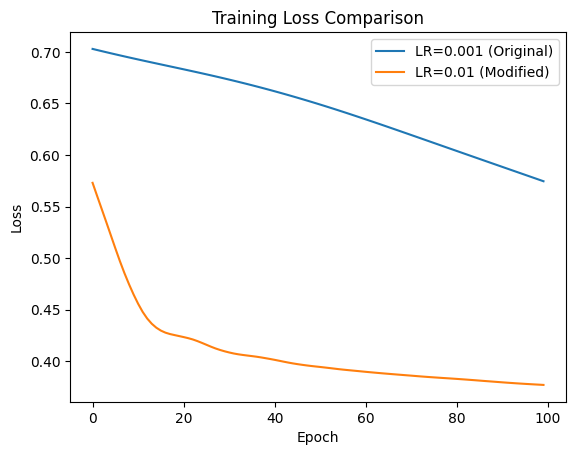

In [106]:
plt.plot(loss_history, label='LR=0.001 (Original)')
plt.plot(loss_history_high_lr, label='LR=0.01 (Modified)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.show()

**Compare Training**

* Convergence speed:

  - With a higher learning rate (0.01), the model might reach lower loss faster, i.e., it learns more quickly in the early epochs.

  - But too high of a learning rate can also overshoot minima or make training unstable.

* Final performance:

  - If the learning rate is too high, the final loss may oscillate or be higher than the original setup (0.001).

  - If it’s just moderately higher, it might converge slightly faster without hurting final performance.

# Question 07: [ Marks 20 ]


# Training Analysis

Answer the following:

Why must gradients be reset every epoch?

What happens if learning rate is too high?

What happens if learning rate is too small?

Why do we define layers inside the constructor (__init__) and not inside forward()?


## Write Answer 07:

# Training Analysis


1. Why must gradients be reset every epoch?

- PyTorch accumulates gradients by default.
- If we do not reset them with optimizer.zero_grad(), gradients from previous epochs will accumulate and incorrectly influence the current parameter updates.
- Resetting ensures each backward pass only uses gradients from the current batch/epoch.

2. What happens if the learning rate is too high?

- The model takes very large steps during weight updates.
- This can cause the loss to fluctuate wildly or even diverge.
- The network may overshoot the optimal solution and fail to converge.

3. What happens if the learning rate is too small?

- The model takes tiny steps during weight updates.
- Convergence becomes very slow, requiring many more epochs.
- The model may get stuck in a local minimum and never reach the best solution.

4. Why do we define layers inside the constructor (__init__) and not inside forward()?

- Layers defined in __init__ are created once when the model is initialized.
- This ensures that the model parameters are properly registered and updated by the optimizer.
- If layers are defined inside forward(), new layers would be created in every forward pass, preventing learning because the optimizer would not update the correct parameters.